<a href="https://colab.research.google.com/github/Kolejking/fake-news-detector-summarizer/blob/main/fake_news_detector%2Bsummarizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nltk
import string

In [25]:
fake_df=pd.read_csv('Fake.csv')
true_df=pd.read_csv('True.csv')

In [26]:
fake_df["label"]=0
true_df["label"]=1
merged_news=pd.concat([fake_df,true_df],axis=0).reset_index(drop=True)
merged_news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [27]:
merged_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [28]:
def remove_punctuation(text):
  return "".join([char for char in text if char not in string.punctuation])

merged_news["text_clean"]=merged_news["text"].apply(lambda x: remove_punctuation(x.lower()))

In [29]:
merged_news.head()

,title,text,subject,date,label,text_clean
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump just couldn t wish all americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,on friday it was revealed that former milwauke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,on christmas day donald trump announced that h...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis used his annual christmas day mes...


In [30]:
merged_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       44898 non-null  object
 1   text        44898 non-null  object
 2   subject     44898 non-null  object
 3   date        44898 non-null  object
 4   label       44898 non-null  int64 
 5   text_clean  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


In [31]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', force=True)
# Using str.split() as a workaround for the NLTK PunktTokenizer issue
merged_news['text_tokens'] = merged_news['text_clean'].apply(lambda x: x.split())
merged_news.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,title,text,subject,date,label,text_clean,text_tokens
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am..."
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev..."
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ..."


In [32]:
nltk.download('punkt', force=True)
# Using str.split() as a workaround for the NLTK PunktTokenizer issue
merged_news['text_token']=merged_news['text_clean'].apply(lambda x: x.split())
merged_news.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,title,text,subject,date,label,text_clean,text_tokens,text_token
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am...","[donald, trump, just, couldn, t, wish, all, am..."
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev..."
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ...","[on, friday, it, was, revealed, that, former, ..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,...","[on, christmas, day, donald, trump, announced,..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ...","[pope, francis, used, his, annual, christmas, ..."


In [33]:

import nltk
nltk.download('stopwords', download_dir='nltk_data')
from nltk.corpus import stopwords
merged_news["text_token"]=merged_news["text_token"].apply(lambda x: [word for word in x if word not in stopwords.words('english')])
merged_news.head()

[nltk_data] Downloading package stopwords to nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title,text,subject,date,label,text_clean,text_tokens,text_token
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am...","[donald, trump, wish, americans, happy, new, y..."
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev..."
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ...","[friday, revealed, former, milwaukee, sheriff,..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,...","[christmas, day, donald, trump, announced, wou..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ...","[pope, francis, used, annual, christmas, day, ..."


In [34]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()
merged_news["text_token"]=merged_news["text_token"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
merged_news["text_final"]=merged_news["text_token"].apply(lambda x: ' '.join(x))
merged_news.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,title,text,subject,date,label,text_clean,text_tokens,text_token,text_final
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am...","[donald, trump, wish, american, happy, new, ye...",donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev...",house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ...","[friday, revealed, former, milwaukee, sheriff,...",friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,...","[christmas, day, donald, trump, announced, wou...",christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ...","[pope, francis, used, annual, christmas, day, ...",pope francis used annual christmas day message...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

tfidf = TfidfVectorizer(ngram_range=(1,1), max_features=5000)
text_tfidf = tfidf.fit_transform(merged_news['text_final']).toarray()
merged_news['body_len']=merged_news['text'].apply(lambda x: len(x)-x.count(' '))

def count_punct(text):
  words=text.split()
  if len(words)==0:
    return 0
  punct_count=sum([1 for char in text if char in string.punctuation])
  return round(punct_count / len(words), 3) * 100

merged_news['punct_per_word%'] = merged_news['text'].apply(count_punct)

def count_cap_words(text):
    words = text.split()
    if len(words) == 0:
        return 0
    cap_count = sum(1 for char in text if char.isupper())
    return round(cap_count / len(words), 3) * 100

merged_news['cap_per_word%'] = merged_news['text'].apply(count_cap_words)

# Combine TF-IDF with engineered features
features_df = pd.DataFrame(text_tfidf, columns=tfidf.get_feature_names_out())
features_df['body_len'] = merged_news['body_len']
features_df['punct_per_word%'] = merged_news['punct_per_word%']
features_df['cap_per_word%'] = merged_news['cap_per_word%']

# Scaling
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df)

# Final DataFrame
final_df = pd.DataFrame(features_scaled, columns=features_df.columns)

final_df.head()

Accuracy: 0.9947661469933184

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



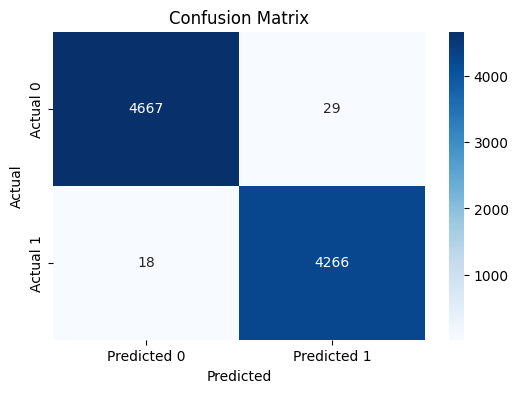

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
X = final_df
y = merged_news['label']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


Random Forest
Accuracy: 0.9985523385300669
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



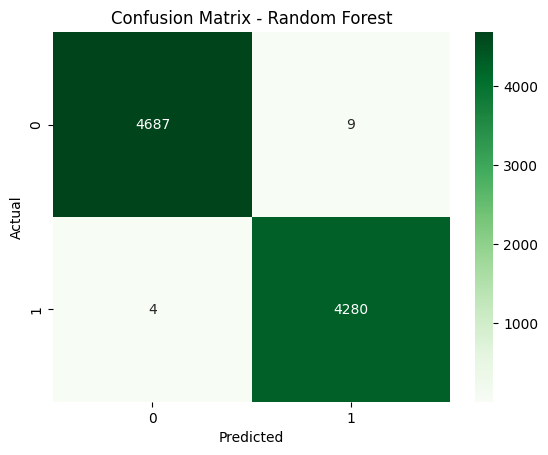

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
from transformers import pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [40]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

model_name = "facebook/bart-large-cnn"

try:
    # Load tokenizer and model directly
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # Create a pipeline using the loaded tokenizer and model
    summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)
    print(f"Successfully loaded summarization model: {model_name}")

    # You can test it with a small example to confirm
    test_text = "Hello, I am a model that can summarize text. This is a test sentence to check if the summarizer is working correctly."
    summary = summarizer(test_text, max_length=20, min_length=5, do_sample=False)
    print("Test summary:", summary[0]['summary_text'])

except Exception as e:
    print(f"Error loading summarization model: {e}")

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Error loading summarization model: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


In [41]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/bart-large-cnn"

try:
    # Load tokenizer and model directly
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    print(f"Successfully loaded tokenizer and model for: {model_name}")

    # Test summarization directly without using the pipeline object for the task
    test_text = "Hello, I am a model that can summarize text. This is a test sentence to check if the summarizer is working correctly."
    inputs = tokenizer([test_text], max_length=1024, return_tensors='pt', truncation=True)

    # Generate summary
    summary_ids = model.generate(inputs['input_ids'], num_beams=4, min_length=5, max_length=20, early_stopping=True)
    summary_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print("Test summary (direct generation):", summary_text)
    print("Model components are working for summarization.")

except Exception as e:
    print(f"Error during direct summarization test: {e}")

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Successfully loaded tokenizer and model for: facebook/bart-large-cnn
Test summary (direct generation): Hello, I am a model that can summarize text. This is a test sentence to
Model components are working for summarization.


In [47]:
def summarize_long_text(text):
    words = text.split()

    # split into chunks (important)
    chunks = [" ".join(words[i:i+200]) for i in range(0, len(words), 200)]

    summaries = []

    for chunk in chunks:
        # Direct summarization using tokenizer and model
        inputs = tokenizer([chunk], max_length=1024, return_tensors='pt', truncation=True)
        summary_ids = model.generate(
            inputs['input_ids'],
            num_beams=4,
            min_length=20,
            max_length=80,
            early_stopping=True,
            do_sample=False
        )
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        summaries.append(summary)

    return " ".join(summaries)

In [48]:
def predict_and_summarize(news_text):

    # ===== SAME preprocessing =====
    text_clean = "".join([char for char in news_text if char not in string.punctuation]).lower()
    tokens = text_clean.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    text_final = " ".join(tokens)

    # ===== TF-IDF =====
    text_tfidf = tfidf.transform([text_final]).toarray()

    # ===== Extra features =====
    body_len = len(news_text) - news_text.count(' ')
    punct = count_punct(news_text)
    caps = count_cap_words(news_text)

    features = np.concatenate([text_tfidf[0], [body_len, punct, caps]])

    # Scale
    features_scaled = scaler.transform([features])

    # ===== Prediction =====
    prediction = rf.predict(features_scaled)[0]
    confidence = rf.predict_proba(features_scaled).max()

    # ===== Output =====
    if prediction == 1:
        print("🟢 TRUE NEWS")
        print("Confidence:", round(confidence, 2))

        summary = summarize_long_text(news_text)

        print("\n📝 Summary:")
        print(summary)

    else:
        print("🔴 FAKE NEWS")
        print("Confidence:", round(confidence, 2))
        print("⚠️ This news may be misleading")

In [49]:
sample_news = true_df['text'].iloc[0]  # pick any real news

predict_and_summarize(sample_news)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🟢 TRUE NEWS
Confidence: 1.0

📝 Summary:
U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget. President Donald Trump and his Republicans want a big budget increase in military spending. Meadows was among Republicans who voted in late December for their party’s debt-financed tax overhaul. The tax overhaul is expected to balloon the federal budget deficit and add about $1.5 trillion over 10 years to the national debt. Republicans insist the tax package will boost the economy and job growth. tax bill, recently went further than Meadows, making clear in a radio interview that welfare or "entitlement reform" would be a top Republican priority in 2018. Democrats seized on Ryan’s early December remarks, saying they showed Republicans would try to pay for their tax overhaul by seeking spending cuts for social programs. messages he wants fu

In [50]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
